### Requirements

In [1]:

!pip install pandas numpy matplotlib seaborn scikit-learn

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

### Loading Dataset

In [3]:
uploaded = files.upload()

Saving Country-data.csv to Country-data.csv


In [4]:
df = pd.read_csv(next(iter(uploaded)))

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.describe(include="all")

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
unique,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,NaN,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,NaN,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,NaN,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,NaN,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,NaN,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000


### Cleaning


In [7]:
print("Missing Val: ")
print(df.isnull().sum())

print("Duplicated : ", df.duplicated().sum())

Missing Val: 
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
Duplicated :  0


### EDA

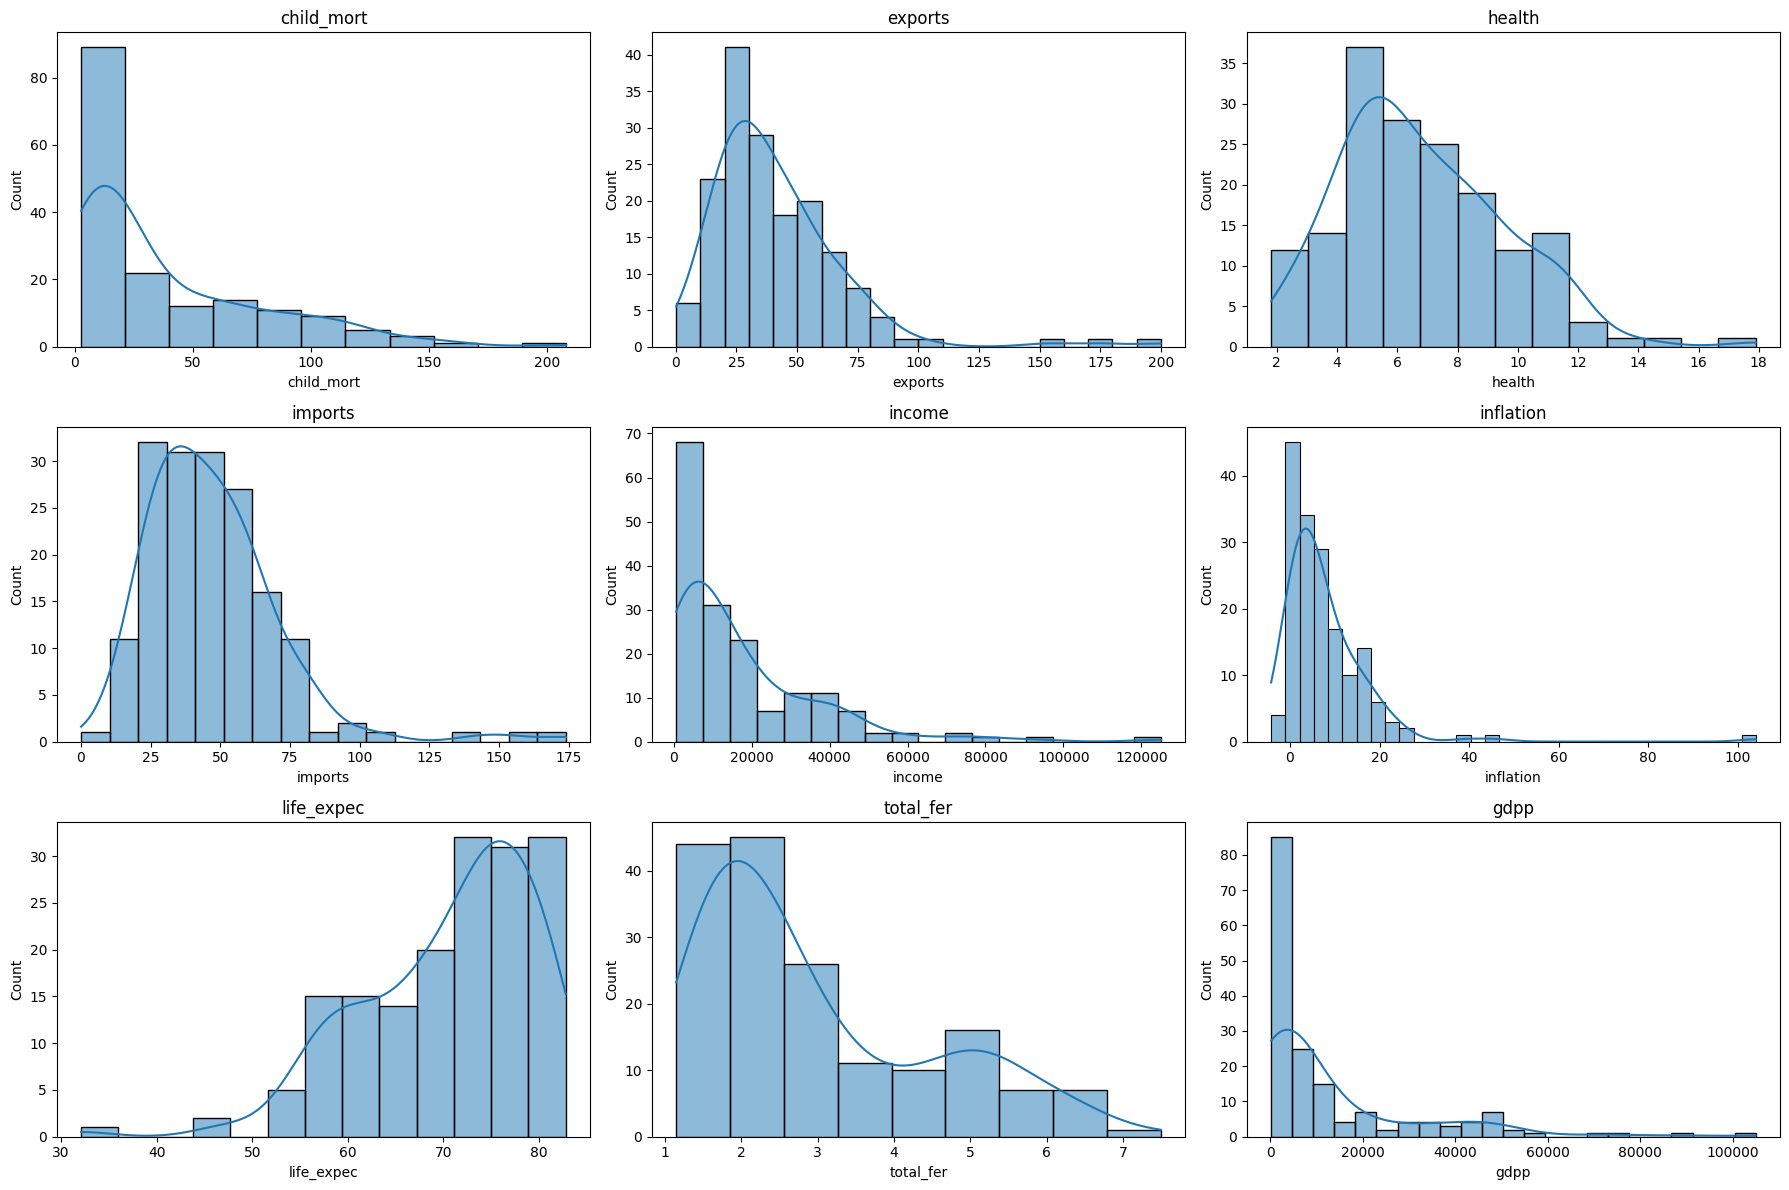

In [8]:
plt.figure(figsize=(18, 12))

numeric_cols = df.select_dtypes(include=np.number).columns

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

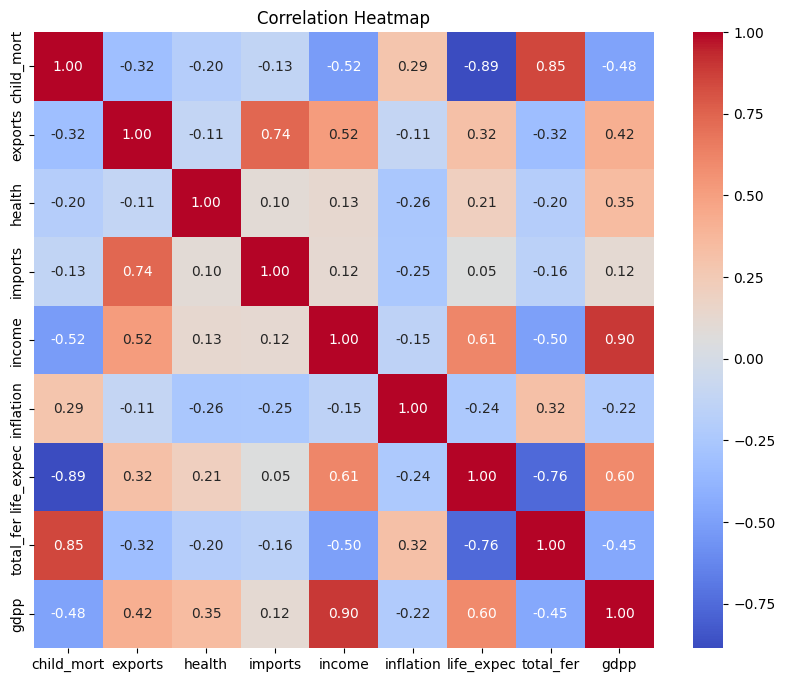

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
df.columns = df.columns.str.strip()
df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


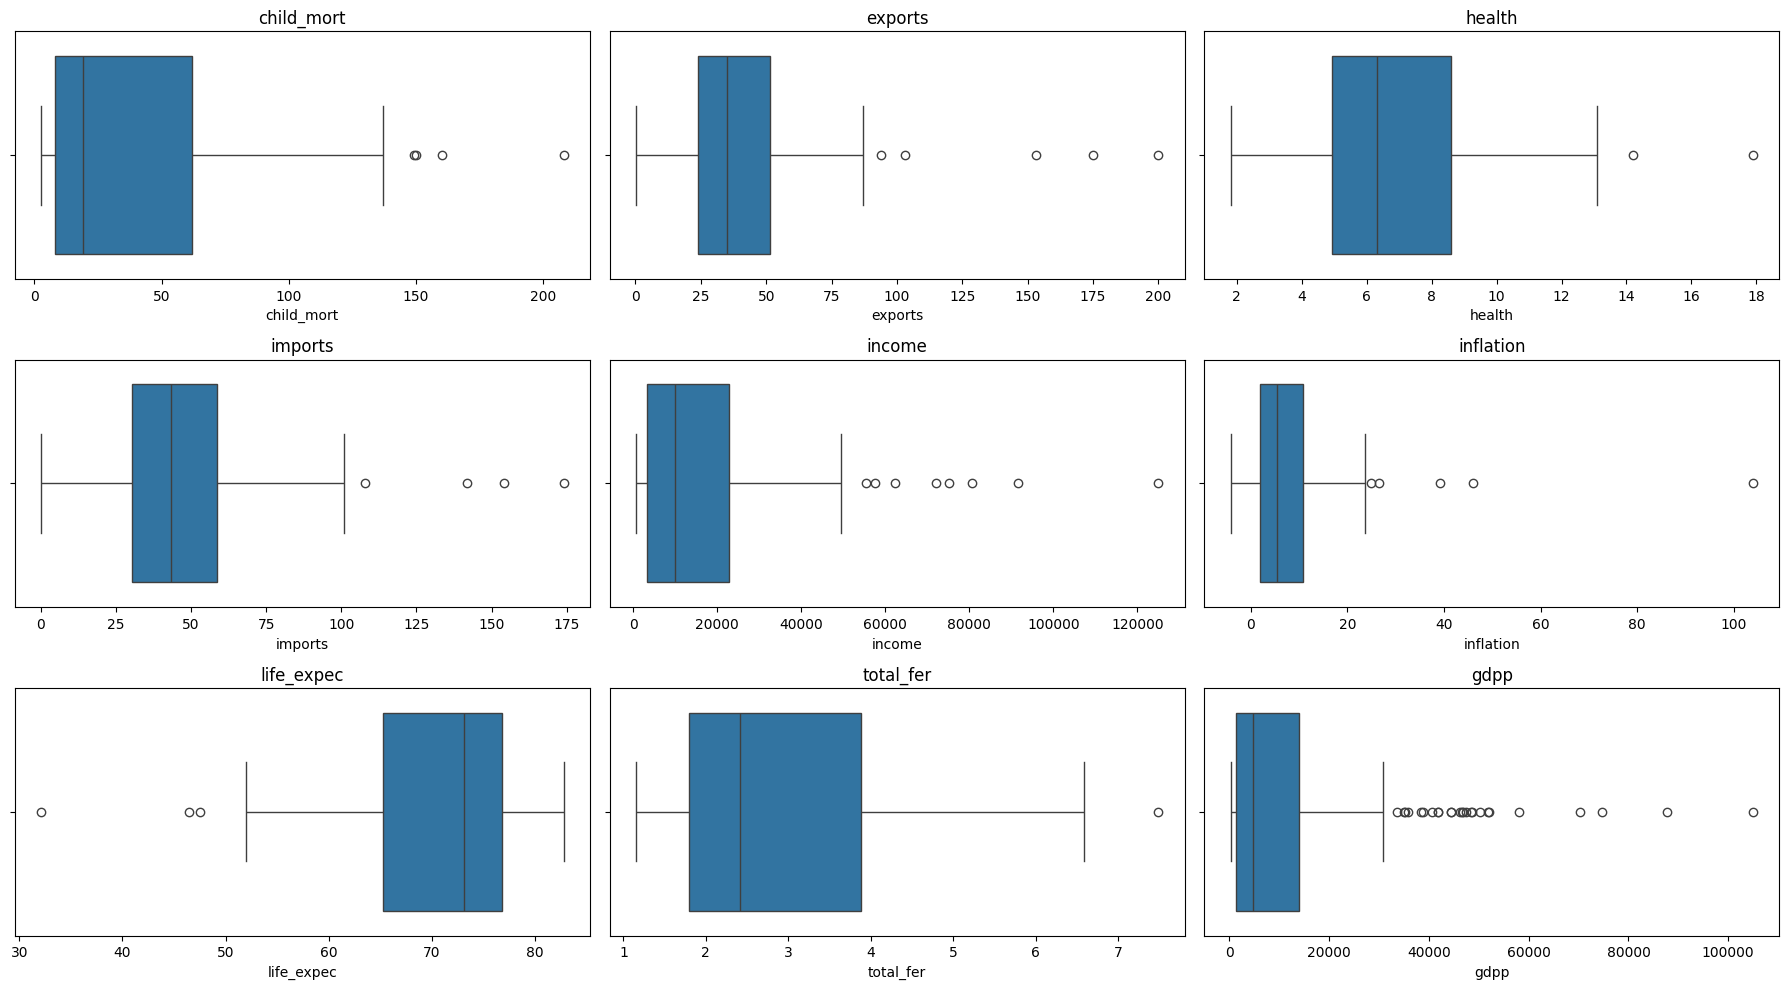

In [11]:
plt.figure(figsize=(18, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Feature Scaling

In [12]:
X = df.drop("country", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(167, 9)

K-Means - Elbow method

In [13]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

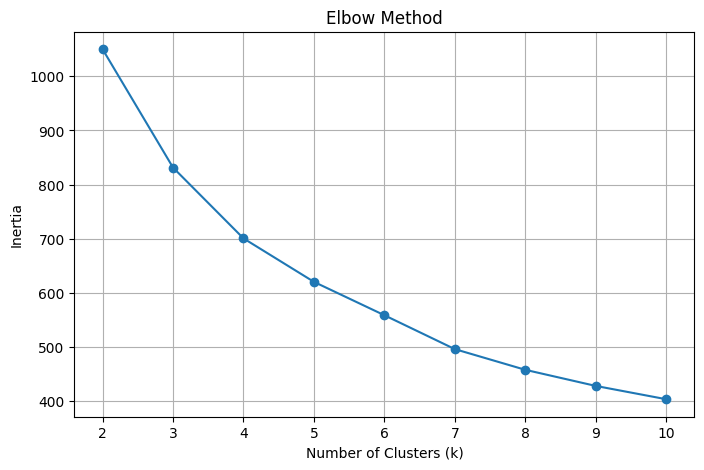

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

### K-Means

In [15]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print("Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))

Silhouette Score: 0.28329575683463126


### DBSCAN

In [16]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Cluster Labels:")
print(np.unique(dbscan_labels))

print("Silhouette Score:", silhouette_score(X_scaled, dbscan_labels))

DBSCAN Cluster Labels:
[-1  0]
Silhouette Score: 0.28829596251907025


In [17]:
print("K-Means Cluster Counts")
print(df["KMeans_Cluster"].value_counts().sort_index())

print("\nDBSCAN Cluster Counts")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

print("\nNumber of DBSCAN Noise Points:", (df["DBSCAN_Cluster"] == -1).sum())

K-Means Cluster Counts
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64

DBSCAN Cluster Counts
DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64

Number of DBSCAN Noise Points: 30


### PCA

In [18]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

pca_df["KMeans"] = kmeans_labels
pca_df["DBSCAN"] = dbscan_labels

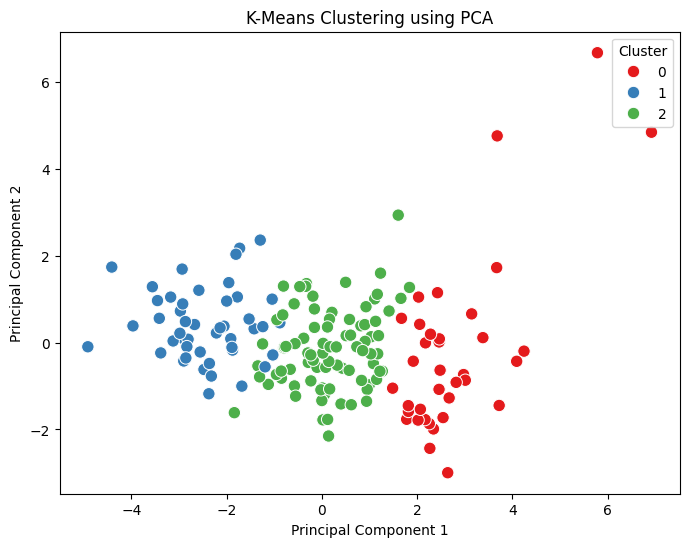

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="KMeans",
    palette="Set1",
    s=80
)

plt.title("K-Means Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

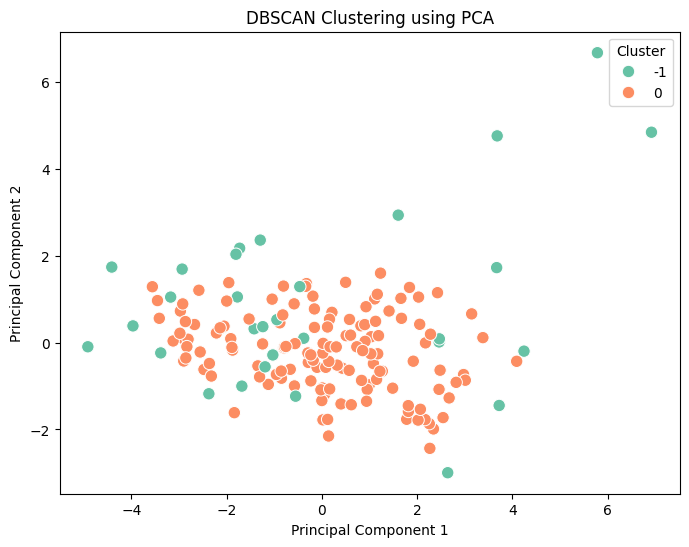

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    palette="Set2",
    s=80
)

plt.title("DBSCAN Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [21]:
cluster_summary = df.groupby("KMeans_Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


### Observations

1. **Cluster 0** — high income, high development, good average income (~$45.7k), low child mortality, higher life expectancy.
2. Cluster 0 countries are good markets: higher spending capacity since daily requirements are already satisfied, so luxury products can succeed here.
3. **Cluster 1** — high mortality, very low income, poor health outcomes, lower life expectancy, high inflation. This is the priority cluster for aid/intervention.
4. **Cluster 2** — moderate income, growing GDP, representing transitional economies.
5. Cluster 2 countries are good markets to invest in: developing economies with good human resources, suited for daily-use items and industrialization.